# RÓŻNE RODZAJE INTERPOLACJI

**Postawienie problemu interpolacji:**

Mamy dane

$$ x_0 < x_1 < \\ldots < x_n \quad (\\text{węzły interpolacji}) $$

$$ y_0, y_1, \\ldots, y_n \quad (\\text{wartości funkcji w węzłach}) $$

Znajdź ciągłą funkcję $f(x)$ na $[x_0, x_n]$ taką że:

$$ f(x_k) = y_k \quad \\text{dla } k = 0, 1, \\ldots, n $$

Istnieje wiele rodzajów interpolacji — różnią się rodziną funkcji bazowych oraz warunkami brzegowymi.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, make_interp_spline, PchipInterpolator

# Wspólne dane do wszystkich przykładów
x = np.array([2, 3, 6, 7, 8, 10])
y = np.array([0, 2, 4, 5, 1, 2])
xx = np.linspace(0, 11, 401)

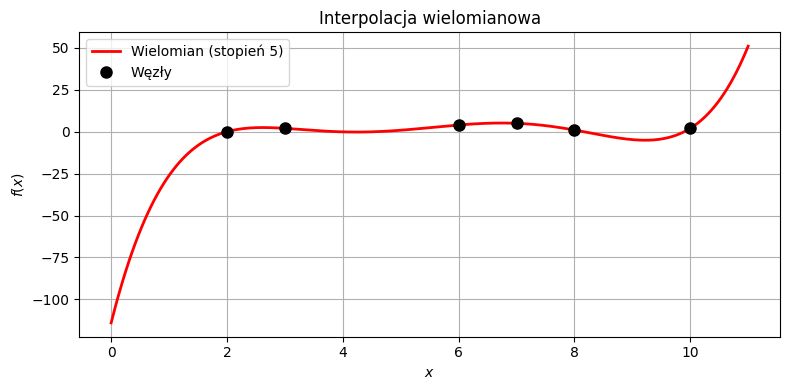

In [2]:
# 1. Interpolacja wielomianowa
degree = len(x) - 1
coeffs = np.polyfit(x, y, degree)
yy_poly = np.polyval(coeffs, xx)

fig, ax = plt.subplots(figsize=(8, 4))
label_text = f"Wielomian (stopień {degree})"
ax.plot(xx, yy_poly, 'r-', linewidth=2, label=label_text)
ax.plot(x, y, 'ko', markersize=8, label='Węzły')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Interpolacja wielomianowa')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

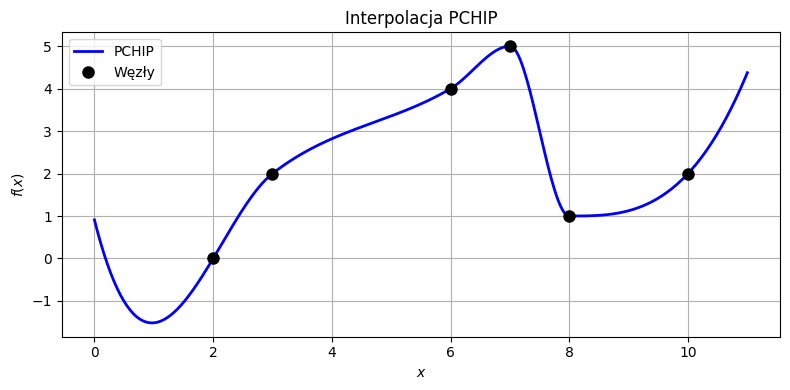

In [3]:
# 2. Interpolacja PCHIP (Piecewise Cubic Hermite Interpolating Polynomial)
pchip = PchipInterpolator(x, y)
yy_pchip = pchip(xx)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xx, yy_pchip, 'b-', linewidth=2, label='PCHIP')
ax.plot(x, y, 'ko', markersize=8, label='Węzły')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Interpolacja PCHIP')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

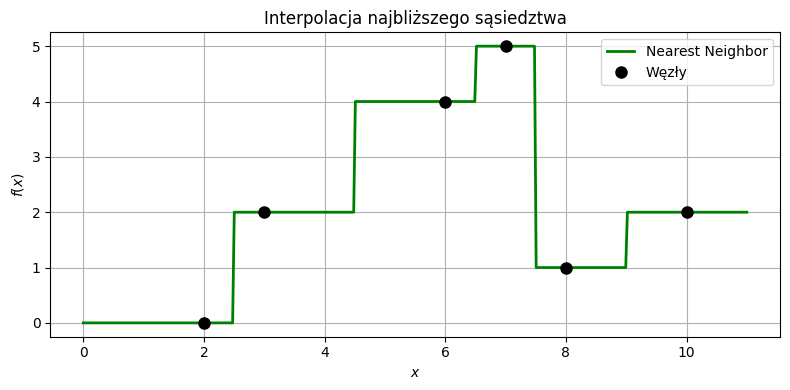

In [4]:
# 3. Interpolacja najbliższego sąsiedztwa (nearest neighbor)
nn_interp = interp1d(x, y, kind='nearest', fill_value='extrapolate')
yy_nn = nn_interp(xx)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xx, yy_nn, 'g-', linewidth=2, label='Nearest Neighbor')
ax.plot(x, y, 'ko', markersize=8, label='Węzły')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Interpolacja najbliższego sąsiedztwa')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

---

## Porównanie metod

| Metoda | Zalety | Wady |
|---|---|---|
| Wielomianowa | Prosta, analityczna | Zjawisko Rungego przy dużym stopniu |
| PCHIP | Monotoniczność, brak oscylacji | Tylko $C^1$ |
| Nearest | Prosta, szybka | Niekontynuowalna (skokowa) |

PCHIP zachowuje monotoniczność danych i unika oscylacji, co jest ważne przy danych fizycznych.

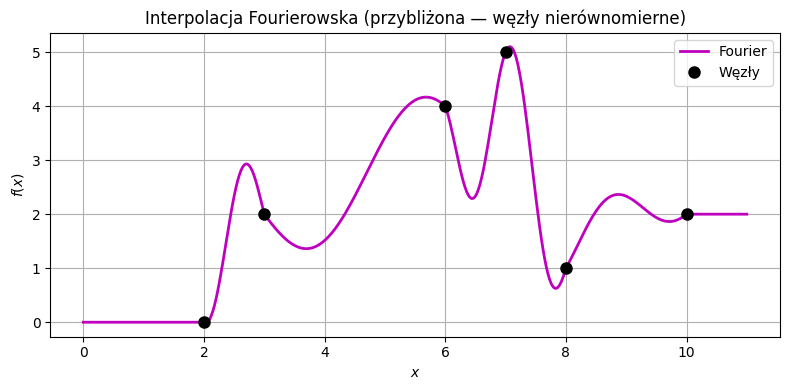

Sprawdzenie przechodzenia przez węzły (przybliżone, patrz uwaga wyżej):
  x[0]=2  y=0  interp=-0.0059  diff=5.93e-03
  x[1]=3  y=2  interp=2.0114  diff=1.14e-02
  x[2]=6  y=4  interp=4.0050  diff=5.00e-03
  x[3]=7  y=5  interp=5.0313  diff=3.13e-02
  x[4]=8  y=1  interp=1.0049  diff=4.92e-03
  x[5]=10  y=2  interp=2.0000  diff=4.44e-16


In [5]:
# 4. Interpolacja Fourierowska
# UWAGA: baza Fouriera zakłada węzły równomiernie rozłożone. Nasze węzły x
# NIE są równomierne, więc poniżej jedynie doraźnie "urealniamy" oś x na
# przestrzeń indeksów (np.interp) — to przybliżenie, nie ścisła
# interpolacja: funkcja może nie przechodzić dokładnie przez węzły (patrz
# wydruk "Sprawdzenie przechodzenia przez węzły" niżej).
from scipy import fftpack

y_fft = fftpack.fft(y)
N_fft = len(x)

yy_fourier = np.zeros_like(xx)
# Map each xx to continuous index-space (DFT interp works on indices 0..N-1)
t = np.interp(xx, x, np.arange(N_fft))
for idx in range(len(xx)):
    s = 0
    for j in range(N_fft):
        s += y_fft[j] * np.exp(2j * np.pi * j * t[idx] / N_fft)
    yy_fourier[idx] = np.real(s / N_fft)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xx, yy_fourier, 'm-', linewidth=2, label='Fourier')
ax.plot(x, y, 'ko', markersize=8, label='Węzły')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Interpolacja Fourierowska (przybliżona — węzły nierównomierne)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print('Sprawdzenie przechodzenia przez węzły (przybliżone, patrz uwaga wyżej):')
for k in range(len(x)):
    closest = yy_fourier[np.argmin(np.abs(xx - x[k]))]
    print(f'  x[{k}]={x[k]}  y={y[k]}  interp={closest:.4f}  diff={abs(closest-y[k]):.2e}')


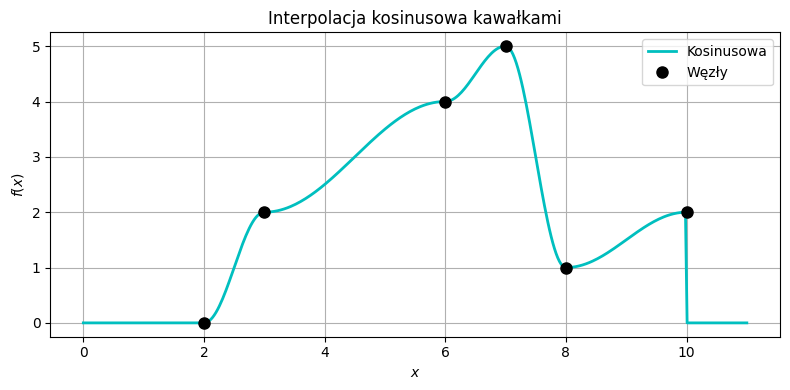

In [6]:
# 5. Kosinusowa interpolacja kawałkami
def cosint_interp(x_nodes, y_nodes, x_eval):
    """Kosinusowa interpolacja kawałkami.

    Na podstawie: Joe Henning, funkcja MATLAB `cosint` (Fall 2011),
    MATLAB Central File Exchange.
    """
    result = np.zeros_like(x_eval, dtype=float)
    for xi in range(len(x_eval)):
        xe = x_eval[xi]
        for j in range(len(x_nodes) - 1):
            if x_nodes[j] <= xe <= x_nodes[j + 1]:
                x_lo, x_hi = x_nodes[j], x_nodes[j + 1]
                y_lo, y_hi = y_nodes[j], y_nodes[j + 1]
                h = x_hi - x_lo
                if h == 0:
                    cfact = 0
                else:
                    cfact = (1 - np.cos(np.pi * (xe - x_lo) / h)) / 2
                result[xi] = y_lo + cfact * (y_hi - y_lo)
                break
    return result

yy_cos = cosint_interp(x, y, xx)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xx, yy_cos, 'c-', linewidth=2, label='Kosinusowa')
ax.plot(x, y, 'ko', markersize=8, label='Węzły')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Interpolacja kosinusowa kawałkami')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

UWAGA: dane zawierają y<=0 (węzeł y=0 przy x=2) -- baza wykładnicza z definicji tego nie obsługuje (log(0) nieokreślony). Wartości przycięte do 1e-10, wynik na odcinku [2,3] jest tylko przybliżeniem awaryjnym, nie prawdziwą interpolacją wykładniczą.


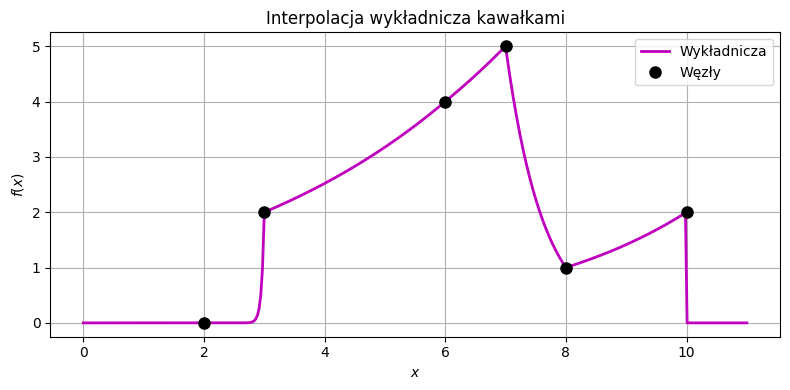

In [7]:
# 6. Wykładnicza interpolacja kawałkami
def expint_interp(x_nodes, y_nodes, x_eval):
    """Wykładnicza interpolacja kawałkami (wymaga y > 0 -- baza log(y) nie
    jest okreslona dla y <= 0).

    Na podstawie: Joe Henning, funkcja MATLAB `expint` (Fall 2012),
    MATLAB Central File Exchange.
    """
    result = np.zeros_like(x_eval, dtype=float)
    # UWAGA: nasze wspólne dane mają y_nodes[0]=0, co łamie założenie y>0 tej
    # metody (log(0) = -inf). Zamiast pozwolić na błąd, "podciągamy" zera do
    # małej wartości dodatniej -- to NIE jest poprawna interpolacja wykładnicza
    # na odcinku [x=2, x=3] (gdzie leży węzeł zerowy), tylko awaryjne obejście,
    # żeby wykres w ogóle dało się narysować. Widać to na wykresie niżej jako
    # spłaszczony/wypłaszczony fragment krzywej blisko x=2-3.
    if np.any(y_nodes <= 0):
        print("UWAGA: dane zawierają y<=0 (węzeł y=0 przy x=2) -- baza wykładnicza "
              "z definicji tego nie obsługuje (log(0) nieokreślony). Wartości "
              "przycięte do 1e-10, wynik na odcinku [2,3] jest tylko przybliżeniem "
              "awaryjnym, nie prawdziwą interpolacją wykładniczą.")
    y_pos = np.maximum(y_nodes, 1e-10)
    for xi in range(len(x_eval)):
        xe = x_eval[xi]
        for j in range(len(x_nodes) - 1):
            if x_nodes[j] <= xe <= x_nodes[j + 1]:
                x_lo, x_hi = x_nodes[j], x_nodes[j + 1]
                y_lo, y_hi = y_pos[j], y_pos[j + 1]
                h = x_hi - x_lo
                if h == 0:
                    efact = 0
                else:
                    efact = (xe - x_lo) / h
                result[xi] = np.exp((1 - efact) * np.log(y_lo) + efact * np.log(y_hi))
                break
    return result

yy_exp = expint_interp(x, y, xx)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xx, yy_exp, 'm-', linewidth=2, label='Wykładnicza')
ax.plot(x, y, 'ko', markersize=8, label='Węzły')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Interpolacja wykładnicza kawałkami')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

---

## Podsumowanie

Różne metody interpolacji nadają się do różnych zastosowań:

- **Wielomianowa**: dobre gdy węzły są bliskie siebie i funkcja jest gładka.
- **PCHIP**: najlepsze przy danych z pomiarów (monotoniczność, brak oscylacji).
- **Kosinusowa / Wykładnicza kawałkami**: gładkie ($C^1$ lub $C^0$) przejścia w każdym odcinku.
- **Fourierowska**: najlepsze dla danych okresowych.

---

## Ćwiczenie

**Ćwiczenie:** Porównaj wszystkie metody interpolacji na tym samym wykresie. Dodaj własną funkcję $f(x)$ z większą liczbą węzłów ($N=20$) i sprawdź, która metoda najlepiej odzwierciedla prawdziwy kształt funkcji.